# Data Exploration & Analysis (EDA)

Quick overview of the dataset structure, ground truth, and noisy images.

In [1]:
import numpy as np
import os
import glob
from pathlib import Path

# Define data paths
train_root = '../data/train'
gt_dir = os.path.join(train_root, 'GT')
noisy_dir = os.path.join(train_root, 'NoisyLR')
test_dir = '../data/test/NoisyLR'

# List available files
gt_files = sorted(glob.glob(os.path.join(gt_dir, '*.npy')))
noisy_files = sorted(glob.glob(os.path.join(noisy_dir, '*.npy')))
test_files = sorted(glob.glob(os.path.join(test_dir, '*.npy')))

print(f"Ground Truth (GT) files: {len(gt_files)}")
print(f"Noisy Low-Res (NoisyLR) files: {len(noisy_files)}")
print(f"Test (NoisyLR) files: {len(test_files)}")
print(f"\nTotal training pairs: {len(gt_files)}")

Ground Truth (GT) files: 3200
Noisy Low-Res (NoisyLR) files: 3200
Test (NoisyLR) files: 400

Total training pairs: 3200


## Load Sample Images

In [2]:
# Load first sample
idx = 0
gt_sample = np.load(gt_files[idx])
noisy_sample = np.load(noisy_files[idx])
test_sample = np.load(test_files[0])

print("Sample 1 - Training Pair:")
print(f"  Ground Truth shape: {gt_sample.shape}")
print(f"  Ground Truth dtype: {gt_sample.dtype}")
print(f"  Ground Truth range: [{gt_sample.min():.4f}, {gt_sample.max():.4f}]")
print()
print(f"  Noisy LR shape: {noisy_sample.shape}")
print(f"  Noisy LR dtype: {noisy_sample.dtype}")
print(f"  Noisy LR range: [{noisy_sample.min():.4f}, {noisy_sample.max():.4f}]")
print()
print(f"Resolution scale (GT/Noisy): {gt_sample.shape[0] / noisy_sample.shape[0]:.1f}x")
print()
print("Test Sample:")
print(f"  Shape: {test_sample.shape}")
print(f"  Range: [{test_sample.min():.4f}, {test_sample.max():.4f}]")

Sample 1 - Training Pair:
  Ground Truth shape: (256, 256)
  Ground Truth dtype: float32
  Ground Truth range: [0.0000, 1.0000]

  Noisy LR shape: (128, 128)
  Noisy LR dtype: float32
  Noisy LR range: [-0.0026, 1.3258]

Resolution scale (GT/Noisy): 2.0x

Test Sample:
  Shape: (128, 128)
  Range: [0.0010, 1.5406]


## Load Multiple Samples & Statistics

In [3]:
# Load multiple samples to get statistics
num_samples = 10
gt_shapes = []
noisy_shapes = []
gt_stats = []
noisy_stats = []

for i in range(num_samples):
    gt = np.load(gt_files[i])
    noisy = np.load(noisy_files[i])
    
    gt_shapes.append(gt.shape)
    noisy_shapes.append(noisy.shape)
    gt_stats.append({'min': gt.min(), 'max': gt.max(), 'mean': gt.mean(), 'std': gt.std()})
    noisy_stats.append({'min': noisy.min(), 'max': noisy.max(), 'mean': noisy.mean(), 'std': noisy.std()})

print("\n=== GROUND TRUTH (GT) ===")
print(f"Unique shapes (first {num_samples} samples): {set(gt_shapes)}")
print(f"\nValue statistics (first {num_samples} samples):")
print(f"  Min:  [{np.array([s['min'] for s in gt_stats]).min():.4f}, {np.array([s['min'] for s in gt_stats]).max():.4f}]")
print(f"  Max:  [{np.array([s['max'] for s in gt_stats]).min():.4f}, {np.array([s['max'] for s in gt_stats]).max():.4f}]")
print(f"  Mean: [{np.array([s['mean'] for s in gt_stats]).mean():.4f}]")
print(f"  Std:  [{np.array([s['std'] for s in gt_stats]).mean():.4f}]")

print("\n=== NOISY LOW-RES (NoisyLR) ===")
print(f"Unique shapes (first {num_samples} samples): {set(noisy_shapes)}")
print(f"\nValue statistics (first {num_samples} samples):")
print(f"  Min:  [{np.array([s['min'] for s in noisy_stats]).min():.4f}, {np.array([s['min'] for s in noisy_stats]).max():.4f}]")
print(f"  Max:  [{np.array([s['max'] for s in noisy_stats]).min():.4f}, {np.array([s['max'] for s in noisy_stats]).max():.4f}]")
print(f"  Mean: [{np.array([s['mean'] for s in noisy_stats]).mean():.4f}]")
print(f"  Std:  [{np.array([s['std'] for s in noisy_stats]).mean():.4f}]")


=== GROUND TRUTH (GT) ===
Unique shapes (first 10 samples): {(256, 256)}

Value statistics (first 10 samples):
  Min:  [0.0000, 0.0000]
  Max:  [1.0000, 1.0000]
  Mean: [0.3364]
  Std:  [0.1497]

=== NOISY LOW-RES (NoisyLR) ===
Unique shapes (first 10 samples): {(128, 128)}

Value statistics (first 10 samples):
  Min:  [-0.0500, 0.0003]
  Max:  [0.8439, 1.5705]
  Mean: [0.3363]
  Std:  [0.1621]


## Visualize Sample Pair

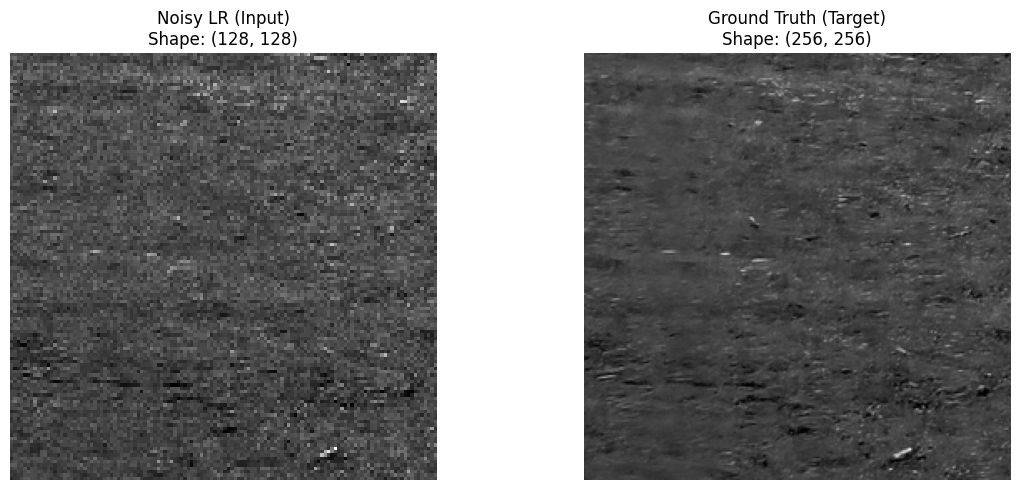


Sample 5:
  Noisy LR: (128, 128) | Values: [-0.006, 0.932]
  Ground Truth: (256, 256) | Values: [0.000, 1.000]
  Scale factor: 2.0x


In [ ]:
try:
    import matplotlib.pyplot as plt
    
    # Load multiple samples for comparison
    num_display = 6
    indices = [0, 5, 10, 50, 100, 150]
    
    # Create figure with 6 samples (3 rows x 4 cols: noisy + gt pairs)
    fig, axes = plt.subplots(num_display, 2, figsize=(10, 16))
    
    for row, idx in enumerate(indices):
        gt = np.load(gt_files[idx])
        noisy = np.load(noisy_files[idx])
        
        # Plot noisy (LR) on left
        axes[row, 0].imshow(noisy, cmap='gray')
        axes[row, 0].set_title(f'Sample {idx}: Noisy LR\n{noisy.shape}', fontsize=10)
        axes[row, 0].axis('off')
        
        # Plot ground truth (HR) on right
        axes[row, 1].imshow(gt, cmap='gray')
        axes[row, 1].set_title(f'Sample {idx}: Ground Truth\n{gt.shape}', fontsize=10)
        axes[row, 1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics for displayed samples
    print(f"\n{'Sample':<8} {'Noisy Shape':<15} {'Noisy Range':<20} {'GT Shape':<15} {'GT Range':<20} {'Scale':<8}")
    print("="*85)
    for idx in indices:
        gt = np.load(gt_files[idx])
        noisy = np.load(noisy_files[idx])
        scale = gt.shape[0] / noisy.shape[0]
        print(f"{idx:<8} {str(noisy.shape):<15} [{noisy.min():.3f}, {noisy.max():.3f}]     {str(gt.shape):<15} [{gt.min():.3f}, {gt.max():.3f}]     {scale:.1f}x")
except ImportError:
    print("Matplotlib not installed. Skipping visualization.")

## Dataset Summary

In [5]:
print("="*60)
print("DATASET SUMMARY")
print("="*60)
print(f"\n📊 TRAINING DATA:")
print(f"   • Total pairs: {len(gt_files)}")
print(f"   • Ground Truth dir: {gt_dir}")
print(f"   • Noisy LR dir: {noisy_dir}")
print(f"   • Typical resolution: LR ~128x128 → GT ~256x256 (2x upscale)")
print(f"\n📊 TEST DATA:")
print(f"   • Total test images: {len(test_files)}")
print(f"   • Test dir: {test_dir}")
print(f"   • Naming: 000000.npy to {len(test_files)-1:06d}.npy")
print(f"\n🎯 TASK:")
print(f"   • Input: Noisy Low-Res grayscale images (LR)")
print(f"   • Output: Restored High-Res grayscale images (HR)")
print(f"   • Goal: Denoising + 2x Super-Resolution")
print(f"\n💾 DATA FORMAT:")
print(f"   • Format: NumPy .npy files (binary)")
print(f"   • Data type: float32")
print(f"   • Value range: [0.0, 1.0]")
print(f"\n" + "="*60)

DATASET SUMMARY

📊 TRAINING DATA:
   • Total pairs: 3200
   • Ground Truth dir: ../data/train\GT
   • Noisy LR dir: ../data/train\NoisyLR
   • Typical resolution: LR ~128x128 → GT ~256x256 (2x upscale)

📊 TEST DATA:
   • Total test images: 400
   • Test dir: ../data/test/NoisyLR
   • Naming: 000000.npy to 000399.npy

🎯 TASK:
   • Input: Noisy Low-Res grayscale images (LR)
   • Output: Restored High-Res grayscale images (HR)
   • Goal: Denoising + 2x Super-Resolution

💾 DATA FORMAT:
   • Format: NumPy .npy files (binary)
   • Data type: float32
   • Value range: [0.0, 1.0]

